## Pandas walkthrough

### Einlesen der Daten

In [67]:
#csv einlesen mit pandas
import pandas as pd
df = pd.read_csv(
    "/Users/nils/TA/Inf2/us_4/demo.csv",
    sep=",",        #sep="," um anzugeben, dass die Spalten durch Kommas getrennt sind
    comment='#', #da unsere demo.csv Kommentare enthält!
    # usecols=['Flugnummer','Airline'] # mit usecols kann man festlegen, wenn man nur gewissse spalten einlesen möchte
) 
    
#verwende head() um die ersten Zeilen des DataFrames anzuzeigen
#hilfreich um zu überprüfen, ob die Daten korrekt eingelesen wurden
df.head()

,Flugnummer,Airline,Zielort,Geplante_Zeit,Gate,Flugzeugtyp,Passagiere,Distanz_mi
0,LX1010,Swiss Int. Air Lines,LHR,07:00,A12,Airbus A320neo,162,491
1,WK402,Edelweiss Air,PMI,07:15,B34,Airbus A320,158,643
2,LH2367,Lufthansa,MUC,08:30,A05,Airbus A319,124,162
3,LX18,Swiss Int. Air Lines,JFK,10:15,E27,Airbus A330-300,221,3927
4,EK88,Emirates,DXB,14:35,E46,Boeing 777-300ER,345,2964


### Meilen in kilometer umrechnen und  meilen löschen

Dazu:
* fügen wir zuerst eine **neue Spalte** "Distanz_km" hinzu
* **löschen wir die "Distanz_mi" Spalte** aus unserem df (wir benötigen sie nicht  mehr)

... und wir zeigen uns das resultat zur sicherheit nochmals über .head() an

In [68]:
#neue spalte hinzufügen
df["Distanz_km"] = (df["Distanz_mi"] * 1.60934).round(0).astype(int) #astype(int) um  ohne .0 anzuzeigen

#spalte entfernen
df.drop("Distanz_mi", axis=1, inplace=True) #axis=1 um die Spalte zu löschen, inplace=True um die Änderung direkt im DataFrame zu speichern


df.head()


,Flugnummer,Airline,Zielort,Geplante_Zeit,Gate,Flugzeugtyp,Passagiere,Distanz_km
0,LX1010,Swiss Int. Air Lines,LHR,07:00,A12,Airbus A320neo,162,790
1,WK402,Edelweiss Air,PMI,07:15,B34,Airbus A320,158,1035
2,LH2367,Lufthansa,MUC,08:30,A05,Airbus A319,124,261
3,LX18,Swiss Int. Air Lines,JFK,10:15,E27,Airbus A330-300,221,6320
4,EK88,Emirates,DXB,14:35,E46,Boeing 777-300ER,345,4770


komplizierteres Beispiel: neue Spalte erstellen, welche sich aus anderen Spalten berechnen lässt

In [69]:
#berechen der passagiere pro kilometer
df["Passagiere_pro_km"] = (df["Passagiere"] / df["Distanz_km"]).round(2) #round(2) um auf 2 Nachkommastellen zu runden
df.head()

,Flugnummer,Airline,Zielort,Geplante_Zeit,Gate,Flugzeugtyp,Passagiere,Distanz_km,Passagiere_pro_km
0,LX1010,Swiss Int. Air Lines,LHR,07:00,A12,Airbus A320neo,162,790,0.21
1,WK402,Edelweiss Air,PMI,07:15,B34,Airbus A320,158,1035,0.15
2,LH2367,Lufthansa,MUC,08:30,A05,Airbus A319,124,261,0.48
3,LX18,Swiss Int. Air Lines,JFK,10:15,E27,Airbus A330-300,221,6320,0.03
4,EK88,Emirates,DXB,14:35,E46,Boeing 777-300ER,345,4770,0.07


### von pandas zu matplotlib..

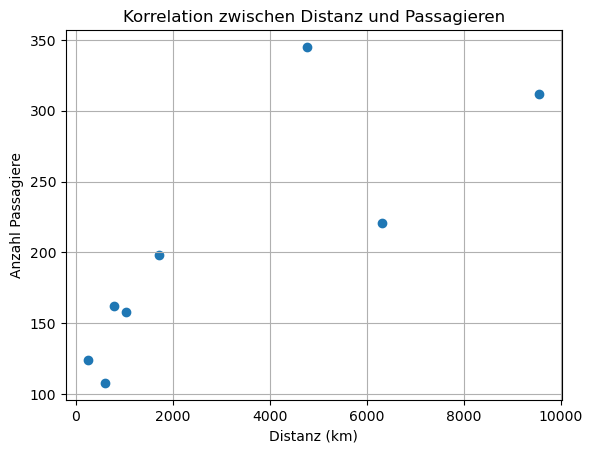

In [70]:
#prüfen, ob es eine Korrelation zwischen der Distanz und der Anzahl Passagiere gibt
import matplotlib.pyplot as plt
X=df["Distanz_km"]
Y=df["Passagiere"]

plt.scatter(X, Y) #wir können direkt ein pandas DataFrame verwenden, um die Spalten zu plotten!
plt.xlabel("Distanz (km)")
plt.ylabel("Anzahl Passagiere")
plt.title("Korrelation zwischen Distanz und Passagieren")
plt.grid()
plt.show()

#print(X) #zeigen was in X steht

### Sortieren und weitere Funktionen

In [71]:
#neues dataframe erstellen und nach passagieren sortieren
df_sorted = df.sort_values(by="Passagiere", ascending=False) #sort_values()
df_sorted.head()

,Flugnummer,Airline,Zielort,Geplante_Zeit,Gate,Flugzeugtyp,Passagiere,Distanz_km,Passagiere_pro_km
4,EK88,Emirates,DXB,14:35,E46,Boeing 777-300ER,345,4770,0.07
7,LX40,Swiss Int. Air Lines,LAX,13:10,E19,Boeing 777-300ER,312,9559,0.03
3,LX18,Swiss Int. Air Lines,JFK,10:15,E27,Airbus A330-300,221,6320,0.03
5,LX2084,Swiss Int. Air Lines,LIS,15:20,A18,Airbus A321neo,198,1725,0.11
0,LX1010,Swiss Int. Air Lines,LHR,07:00,A12,Airbus A320neo,162,790,0.21


### Fehlerhafte dateien

In [72]:
#einlesen von fehlerhaften Daten
#neue datei (mit fehlern einlesen)
df = pd.read_csv("/Users/nils/TA/Inf2/us_4/demo_err.csv",sep=",")
df.head()

,Flugnummer,Airline,Zielort,Geplante_Zeit,Gate,Flugzeugtyp,Passagiere,Distanz_mi
0,LX1010,Swiss Int. Air Lines,LHR,07:00,A12,Airbus A320neo,-,491
1,WK402,Edelweiss Air,PMI,07:15,B34,Airbus A320,158,643
2,LH2367,Lufthansa,MUC,08:30,A05,Airbus A319,-,162
3,LX18,Swiss Int. Air Lines,JFK,10:15,E27,Airbus A330-300,221,3927
4,EK88,Emirates,DXB,14:35,E46,Boeing 777-300ER,345,2964


In [73]:
#feststellen, dass die Spalte Passagiere fehlerhafte Werte enthält
#prüfen, ob es fehlerhafte Werte gibt
print(df.dtypes)

Flugnummer       object
Airline          object
Zielort          object
Geplante_Zeit    object
Gate             object
Flugzeugtyp      object
Passagiere       object
Distanz_mi        int64
dtype: object


**Passagiere wollen wir aber als integers lesen können!**

In [74]:
#strings in der Spalte Passagiere in NaN umwandeln
df["Passagiere"] = pd.to_numeric(df["Passagiere"], errors="coerce") #errors="coerce" um fehlerhafte Werte in NaN umzuwandeln


#oder: mit 0 ersetzen (vorheriges auskommentieren und neu runnen)
df["Passagiere"] = pd.to_numeric(df["Passagiere"], errors="coerce").fillna(0).astype(int) #fillna(0) um NaN durch

df.head()

,Flugnummer,Airline,Zielort,Geplante_Zeit,Gate,Flugzeugtyp,Passagiere,Distanz_mi
0,LX1010,Swiss Int. Air Lines,LHR,07:00,A12,Airbus A320neo,0,491
1,WK402,Edelweiss Air,PMI,07:15,B34,Airbus A320,158,643
2,LH2367,Lufthansa,MUC,08:30,A05,Airbus A319,0,162
3,LX18,Swiss Int. Air Lines,JFK,10:15,E27,Airbus A330-300,221,3927
4,EK88,Emirates,DXB,14:35,E46,Boeing 777-300ER,345,2964


### Filtern

gleiches "Masking" konzept wie in Numpy!

In [ ]:
#filtern der Daten, um nur Flüge mit mehr als 200 Passagieren anzuzeigen
passagiere_filter = df["Passagiere"] > 200  #Sequenz aus Bools (Maske)

df_filtered = df[passagiere_filter] # Maske mit df[df["Spaltenname"] > Wert] applizieren um zu filtern 
df_filtered.head()  

,Flugnummer,Airline,Zielort,Geplante_Zeit,Gate,Flugzeugtyp,Passagiere,Distanz_mi
3,LX18,Swiss Int. Air Lines,JFK,10:15,E27,Airbus A330-300,221,3927
4,EK88,Emirates,DXB,14:35,E46,Boeing 777-300ER,345,2964
7,LX40,Swiss Int. Air Lines,LAX,13:10,E19,Boeing 777-300ER,312,5940


In [81]:
#kombinieren von mehreren Filtern, um nur Flüge mit mehr als 200 Passagieren und einer Distanz von mehr als 3000mi anzuzeigen
distanz_filter = df["Distanz_mi"] > 3000
combined_filter = passagiere_filter & distanz_filter #& für logisches UND, | für logisches ODER
df_filtered_combined = df[combined_filter]
df_filtered_combined.head()

,Flugnummer,Airline,Zielort,Geplante_Zeit,Gate,Flugzeugtyp,Passagiere,Distanz_mi
3,LX18,Swiss Int. Air Lines,JFK,10:15,E27,Airbus A330-300,221,3927
7,LX40,Swiss Int. Air Lines,LAX,13:10,E19,Boeing 777-300ER,312,5940


### Statistik Funktionalitäten von Pandas

In [77]:
#statistische Kennzahlen berechnen
print("Durchschnittliche Anzahl Passagiere:", df["Passagiere"].mean())
print("Median der Anzahl Passagiere:", df["Passagiere"].median())
print('maximale Anzahl Passagiere:', df["Passagiere"].max())

#oder direkt mit describe() alle Kennzahlen auf einmal anzeigen
#print(df["Passagiere"].describe())

Durchschnittliche Anzahl Passagiere: 167.75
Median der Anzahl Passagiere: 178.0
maximale Anzahl Passagiere: 345


### Gruppieren

In [83]:
#anwenden der .groupby() Methode, um die durchschnittliche Anzahl Passagiere pro Fluggesellschaft zu berechnen
df_grouped = df.groupby("Airline")["Passagiere"].mean()

df_grouped.head()

Airline
Austrian Airlines       108.00
Edelweiss Air           158.00
Emirates                345.00
Lufthansa                 0.00
Swiss Int. Air Lines    182.75
Name: Passagiere, dtype: float64

### .loc()

für indexe 1:3 ist auch der **End-Index** enthalten!

In [95]:

airline_fluege = df.loc[1:3, "Airline"] #gibt flug 1,flug2 UND flug 3 zurück! (deren Airlines)
print(airline_fluege) 

# Alle Flüge filtern, bei denen die Distanz über 1000 Meilen liegt
# (Hier nutzen wir .loc für eine Bedingung)
long_haul = df.loc[df["Distanz_mi"] > 1000]
long_haul.head ()




1           Edelweiss Air
2               Lufthansa
3    Swiss Int. Air Lines
Name: Airline, dtype: object


,Flugnummer,Airline,Zielort,Geplante_Zeit,Gate,Flugzeugtyp,Passagiere,Distanz_mi
3,LX18,Swiss Int. Air Lines,JFK,10:15,E27,Airbus A330-300,221,3927
4,EK88,Emirates,DXB,14:35,E46,Boeing 777-300ER,345,2964
5,LX2084,Swiss Int. Air Lines,LIS,15:20,A18,Airbus A321neo,198,1072
7,LX40,Swiss Int. Air Lines,LAX,13:10,E19,Boeing 777-300ER,312,5940


### .iloc()

über index zugreifen, wie in numpy.

**End-Index ist NICHT enthaltten**

In [96]:
# Den Wert in der allerersten Zeile (Index 0) und der zweiten Spalte (Index 1) holen
# (Index 1 ist die Spalte 'Airline')
erste_airline = df.iloc[0, 1]
# Ergebnis: 'Swiss Int. Air Lines'

#.iloc funktioneirt wie "Slicing" in numpy (auch 0 indexiert)
ausschnitt = df.iloc[2:5, :3]
print('erste_airline:',erste_airline)
print('ausschnit  mit iloc:\n',ausschnitt)
df.head()



erste_airline: Swiss Int. Air Lines
ausschnit  mit iloc:
   Flugnummer               Airline Zielort
2     LH2367             Lufthansa     MUC
3       LX18  Swiss Int. Air Lines     JFK
4       EK88              Emirates     DXB


,Flugnummer,Airline,Zielort,Geplante_Zeit,Gate,Flugzeugtyp,Passagiere,Distanz_mi
0,LX1010,Swiss Int. Air Lines,LHR,07:00,A12,Airbus A320neo,0,491
1,WK402,Edelweiss Air,PMI,07:15,B34,Airbus A320,158,643
2,LH2367,Lufthansa,MUC,08:30,A05,Airbus A319,0,162
3,LX18,Swiss Int. Air Lines,JFK,10:15,E27,Airbus A330-300,221,3927
4,EK88,Emirates,DXB,14:35,E46,Boeing 777-300ER,345,2964
